# AI-Based Climate Change Analysis & Prediction System

This notebook demonstrates exploratory data analysis (EDA) and prediction modeling for our synthetic climate dataset.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('../data/climate_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.head()

,Temperature_C,Humidity_pct,Rainfall_mm,AQI
Date,,,,
2018-01-01,14.71,59.14,0.00,92
2018-01-02,18.22,55.57,8.22,71
2018-01-03,16.39,61.17,0.00,96
2018-01-04,15.24,57.08,0.00,79
2018-01-05,11.94,56.19,24.58,87


## 2. Exploratory Data Analysis (EDA)

In [2]:
df.describe()

,Temperature_C,Humidity_pct,Rainfall_mm,AQI
count,1825.000000,1825.000000,1825.000000,1825.000000
mean,25.538225,60.111315,4.085490,58.966575
std,7.280595,11.594413,10.117304,31.010954
min,10.670000,28.220000,0.000000,0.000000
25%,19.000000,50.410000,0.000000,32.000000
50%,25.600000,59.800000,0.000000,58.000000
75%,32.200000,70.060000,1.830000,85.000000
max,40.740000,88.220000,78.110000,131.000000


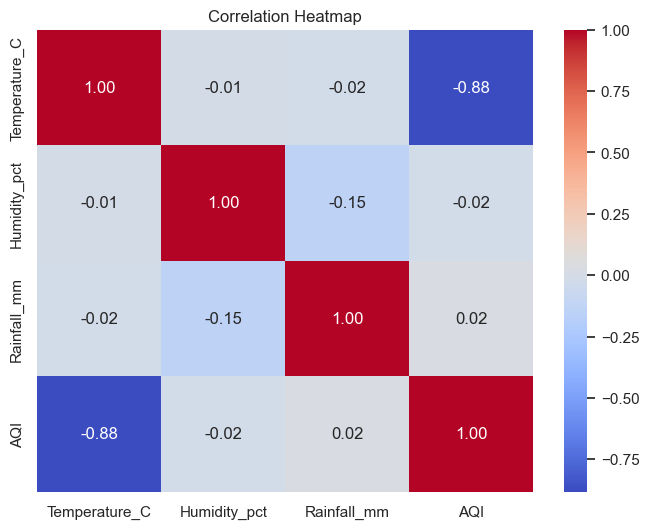

In [3]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

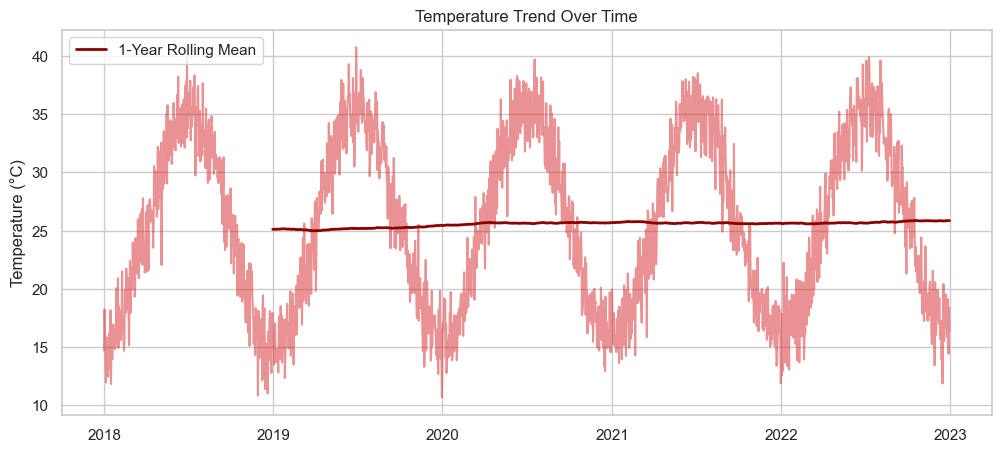

In [4]:
# Temperature Trend Over Time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Temperature_C'], color='tab:red', alpha=0.5)
plt.plot(df.index, df['Temperature_C'].rolling(window=365).mean(), color='darkred', linewidth=2, label='1-Year Rolling Mean')
plt.title('Temperature Trend Over Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

## 3. Data Preprocessing for Machine Learning
We create "lag" features to predict today's temperature based on the past week.

In [5]:
data = df.copy()
for lag in range(1, 8):
    data[f'lag_{lag}'] = data['Temperature_C'].shift(lag)
data.dropna(inplace=True)

X = data.drop(columns=['Temperature_C'])
y = data['Temperature_C']

# Chronological train-test split (80-20)
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

## 4. Model Training & Evaluation

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and Evaluate
rf_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest MAE: {mae:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")

Random Forest MAE: 1.9254
Random Forest RMSE: 2.3803


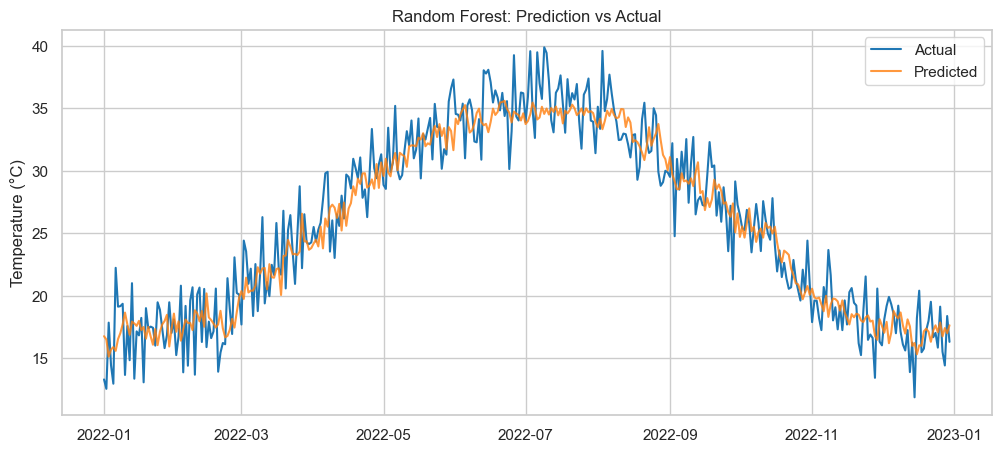

In [7]:
# Plot Predictions vs Actual for the last 365 days
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[-365:], y_test.values[-365:], label='Actual', color='tab:blue')
plt.plot(y_test.index[-365:], rf_pred[-365:], label='Predicted', color='tab:orange', alpha=0.8)
plt.title('Random Forest: Prediction vs Actual')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()